# Showcase of ``sdypy.FRF``

``sdypy-FRF`` is the ``sdypy`` namespace entry to [pyFRF](https://github.com/ladisk/pyFRF): ``sdypy.FRF.FRF`` is the pyFRF ``FRF`` class. The inputs are time signals of excitation and response, the outputs are FRF estimators (H1, H2, Hv or ODS) and coherence.

This example covers a single-input, single-output case. Averaging, impact measurements with overflow and double-impact detection, MIMO systems and more are shown in the full [pyFRF showcase](https://github.com/ladisk/pyFRF/blob/main/Showcase.ipynb).

In [1]:
from sdypy import FRF

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

## Synthetic 3 DOF system

Define the system and obtain its true FRF matrix from the mass, stiffness and damping matrices:

In [2]:
# degrees of freedom:
ndof = 3

# mass matrix:
m = 2
M = np.zeros((ndof, ndof))
np.fill_diagonal(M, m)

# stiffness matrix:
k = 4000000
K = np.zeros((ndof, ndof))

for i in range(K.shape[0] - 1):
    K[i,i] = 2*k
    K[i+1,i] = -k
    K[i,i+1] = -k
K[ndof-1,ndof-1] = k

# damping matrix:
c = 50
C = np.zeros((ndof, ndof))

for i in range(C.shape[0] - 1):
    C[i,i] = 2*c
    C[i+1,i] = -c
    C[i,i+1] = -c
C[ndof-1,ndof-1] = c

# frequencies:
df = 0.5
freq_syn = np.arange(0.0, 2000, df)
omega = 2 * np.pi * freq_syn

# time:
T = 1 / (freq_syn[1] - freq_syn[0])
t = np.linspace(0, T, 2*len(freq_syn)-2)

# synthetic FRF matrix of the system:
FRF_matrix = np.zeros([M.shape[0], M.shape[0], len(freq_syn)], dtype="complex128")  # full system 3x3 FRF matrix
for i, omega_i in enumerate(omega):
    FRF_matrix[:,:,i] = scipy.linalg.inv(K - omega_i**2 * M + 1j*omega_i*C)

We focus on the first DOF (single input, single output). The excitation is a unit impulse, so the response is the inverse FFT of the FRF:

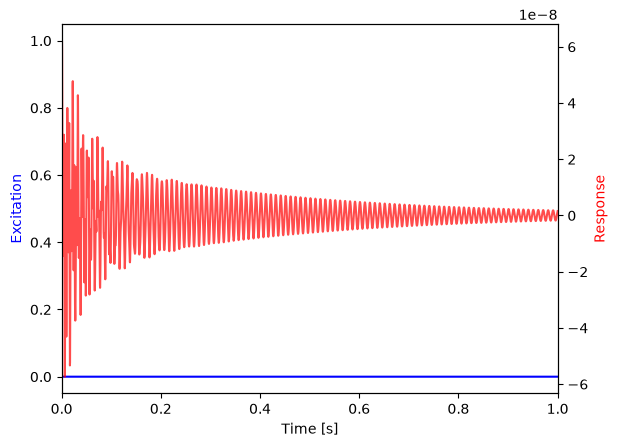

In [3]:
H1_syn = FRF_matrix[0,0,:]

# impulse:
exc = np.zeros_like(t)
exc[0] = 1

# impulse response:
resp = np.fft.irfft(H1_syn)

fig, ax1 = plt.subplots()
ax1.plot(t, exc, 'b')
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Excitation', color='b')
ax1.set_xlim(left=0, right=1)
ax2 = ax1.twinx()
ax2.plot(t, resp, 'r', alpha=0.7)
ax2.set_ylabel('Response', color='r');

## FRF estimate with ``sdypy.FRF``

Create the ``FRF`` object from the time signals, then request an FRF by estimator (``frf_estimator``: ``'H1'``, ``'H2'``, ``'Hv'`` or ``'ODS'``) and form (``frf_form``: ``'receptance'``, ``'mobility'`` or ``'accelerance'``):

In [4]:
frf_object = FRF.FRF(sampling_freq=int(1/t[1]), exc=exc, resp=resp, resp_type='d', frf_estimator='H1')

H1_sdypy = frf_object.get_FRF(frf_estimator='H1', frf_form='receptance')  # shape (response DOF, excitation DOF, frequency points)
freq_sdypy = frf_object.get_f_axis()
H1_sdypy.shape

(1, 1, 4000)

Comparison with the synthetic FRF:

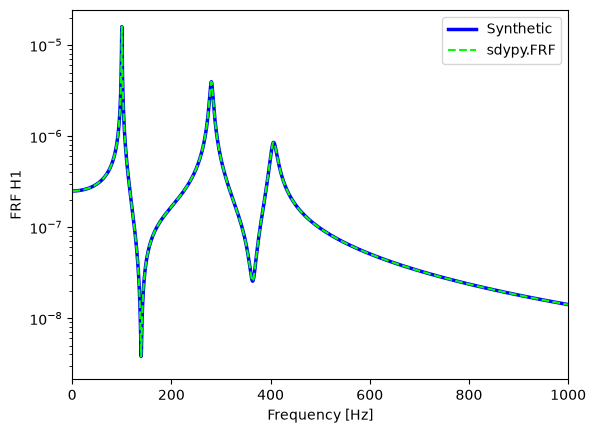

In [5]:
plt.semilogy(freq_syn[1:], np.abs(H1_syn)[1:], "b", label='Synthetic', lw=2.5)
plt.semilogy(freq_sdypy[1:], np.abs(H1_sdypy)[0,0,1:], "--", color="lime", label='sdypy.FRF')
plt.xlim(left=0, right=1000)
plt.xlabel('Frequency [Hz]')
plt.ylabel('FRF H1')
plt.legend();

The same estimate in the three FRF forms:

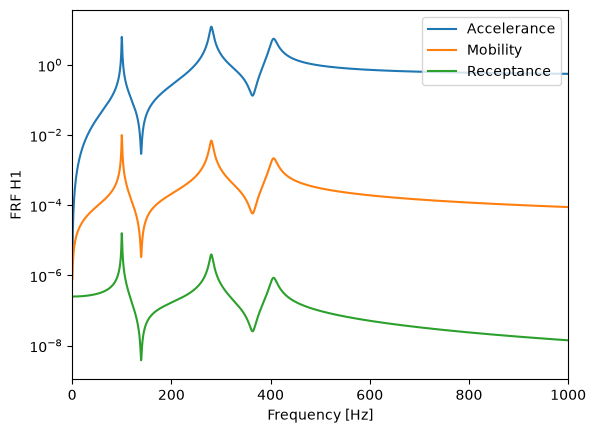

In [6]:
plt.semilogy(freq_sdypy[1:], np.abs(frf_object.get_FRF(frf_form='accelerance'))[0,0,1:], label='Accelerance')
plt.semilogy(freq_sdypy[1:], np.abs(frf_object.get_FRF(frf_form='mobility'))[0,0,1:], label='Mobility')
plt.semilogy(freq_sdypy[1:], np.abs(frf_object.get_FRF(frf_form='receptance'))[0,0,1:], label='Receptance')
plt.xlim(left=0, right=1000)
plt.xlabel('Frequency [Hz]')
plt.ylabel('FRF H1')
plt.legend(loc=1);

## SEP-005 input

``sdypy.FRF`` also exposes ``assert_sep005``. The ``FRF`` object accepts [SEP-005](https://github.com/sdypy/sdypy/blob/main/docs/seps/sep-0005.rst) timeseries directly, in which case the sampling frequency comes from the data:

In [7]:
exc_sep005 = [{'data': exc[np.newaxis, :], 'fs': int(1/t[1]), 'name': 'excitation', 'quantity': 'f', 'unit_str': 'N'}]
resp_sep005 = [{'data': resp[np.newaxis, :], 'fs': int(1/t[1]), 'name': 'response', 'quantity': 'd', 'unit_str': 'm'}]

FRF.assert_sep005(exc_sep005)
FRF.assert_sep005(resp_sep005)

frf_object_sep005 = FRF.FRF(sampling_freq=None, exc=exc_sep005, resp=resp_sep005, frf_estimator='H1')
np.array_equal(frf_object_sep005.get_FRF(), H1_sdypy)

True

## Old and new names

sdypy-FRF 0.3 (pyFRF 1.5) renamed the constructor argument `frf_type` to `frf_estimator`, and the `get_FRF` arguments `type` and `form` to `frf_estimator` and `frf_form`, following the SDyPy nomenclature in [SEP 2](https://github.com/sdypy/sdypy/blob/main/docs/seps/sep-0002.rst). The old spellings still work and emit a `DeprecationWarning`; they will be removed in the next major version.

In [ ]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter('always', DeprecationWarning)

    H_new = frf_object.get_FRF(frf_estimator='H1', frf_form='receptance')  # new names
    H_old = frf_object.get_FRF(type='H1', form='receptance')               # old names: DeprecationWarning
    frf_old = FRF.FRF(sampling_freq=int(1/t[1]), exc=exc, resp=resp, resp_type='d', frf_type='H1')  # old name: DeprecationWarning

print(np.array_equal(H_new, H_old), frf_old.frf_estimator)